# Indonesian Poverty Tweet Sentiment Analysis with RoBERTa (2021-2026)

This notebook analyzes sentiment in Indonesian tweets related to poverty using an Indonesian RoBERTa-based sentiment classifier. The results provide national-level qualitative context and are not attributed to provinces.

In [1]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Library Imports

In [2]:
!pip install transformers torch datasets sentencepiece -q
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud -q
!pip install nltk Sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.4 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
import string
from pathlib import Path
import warnings
from collections import Counter
from datetime import datetime

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)
from sklearn.metrics import classification_report, confusion_matrix

import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
TWEET_DATA_PATH = '/content/kemiskinan_tweets_2021_2026/kemiskinan_tweets_2021_2026.csv'
OUTPUT_DIR = Path('sentiment_output')
OUTPUT_DIR.mkdir(exist_ok=True)

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13

device = 0 if torch.cuda.is_available() else -1
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'

print(f'Device: {"CUDA" if device == 0 else "CPU"} ({device_name})')
print(f'PyTorch version: {torch.__version__}')
import transformers
print(f'Transformers version: {transformers.__version__}')

Device: CUDA (Tesla T4)
PyTorch version: 2.10.0+cu128
Transformers version: 5.0.0


## Tweet Data Loading and Exploration

In [17]:
df_raw = pd.read_csv(TWEET_DATA_PATH)
df_raw = df_raw.rename(columns={
    'waktu': 'timestamp',
    'teks': 'text',
    'tanggal': 'date',
    'tahun': 'year',
    'bulan': 'month',
    'bahasa': 'language'
})

print('Tweet Dataset Information')
print(f'Number of tweets     : {len(df_raw)}')
print(f'Columns     : {df_raw.shape[1]}')
print(f'Columns            : {df_raw.columns.tolist()}')
print(f'Year range    : {df_raw["year"].min()} - {df_raw["year"].max()}')
print(f'Unique languages      : {df_raw["language"].unique()}')
print()
print('First 5 Rows')
df_raw[['timestamp', 'text', 'like', 'retweet', 'year', 'month']].head()

Tweet Dataset Information
Number of tweets     : 521
Columns     : 19
Columns            : ['conversation_id_str', 'timestamp', 'like', 'text', 'tweet_id', 'image_url', 'in_reply_to_screen_name', 'language', 'location', 'quote', 'reply', 'retweet', 'tweet_url', 'user_id_str', 'username', 'tahun_scraping', 'year', 'month', 'date']
Year range    : 2021 - 2026
Unique languages      : ['in']

First 5 Rows


,timestamp,text,like,retweet,year,month
0,2021-12-28 22:17:53+07:00,"Menurut BPS, Persentase penduduk miskin pada M...",0,0,2021,12
1,2021-12-27 21:20:59+07:00,Persentase penduduk miskin Balikpapan pada 202...,0,0,2021,12
2,2021-12-23 05:55:04+07:00,"Persentase penduduk miskin di Kota Sawahlunto,...",1,0,2021,12
3,2021-12-23 02:49:58+07:00,10 Kabupaten/Kota di Aceh dengan Persentase Pe...,0,2,2021,12
4,2021-12-17 17:00:01+07:00,Persentase penduduk miskin dan ketimpangan yan...,1,1,2021,12


In [18]:
print('Tweet Distribution by Year')
per_year = df_raw['year'].value_counts().sort_index()
print(per_year.to_string())

print()
print('Engagement Statistics')
print(df_raw[['like', 'retweet', 'reply', 'quote']].describe().round(2).to_string())

print()
print('Missing Values')
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string())


Tweet Distribution by Year
year
2021     94
2022    100
2023    100
2024     87
2025    100
2026     40

Engagement Statistics
          like  retweet   reply   quote
count   521.00   521.00  521.00  521.00
mean     10.66     3.47    2.31    0.55
std      82.03    31.04   17.29    6.29
min       0.00     0.00    0.00    0.00
25%       0.00     0.00    0.00    0.00
50%       0.00     0.00    0.00    0.00
75%       2.00     1.00    1.00    0.00
max    1608.00   671.00  318.00  133.00

Missing Values
image_url                  330
in_reply_to_screen_name    309
location                   521


In [21]:
per_month = df_raw['month'].value_counts().sort_index()
likes_nonzero = df_raw[df_raw['like'] > 0]['like']
df_raw['length_text'] = df_raw['text'].apply(len)

fig_eda = make_subplots(rows=2, cols=2, subplot_titles=("Number of Tweets by Year", "Tweet Distribution by Month (All Years)", "Log(likes + 1) Distribution", "Tweet Text Length Distribution"))
fig_eda.add_trace(go.Bar(x=per_year.index, y=per_year.values, marker_color='steelblue'), row=1, col=1)
fig_eda.add_trace(go.Bar(x=per_month.index, y=per_month.values, marker_color='#4472C4'), row=1, col=2)
fig_eda.add_trace(go.Histogram(x=np.log1p(likes_nonzero), nbinsx=30, marker_color='#70AD47'), row=2, col=1)
fig_eda.add_trace(go.Histogram(x=df_raw['length_text'], nbinsx=30, marker_color='#FF7F00'), row=2, col=2)
fig_eda.update_layout(height=800, width=1200, showlegend=False, title_text="Indonesian Poverty Tweet Data Exploration 2021-2026")
fig_eda.write_json(OUTPUT_DIR / 'plot_tweet_eda.json')
fig_eda.show()

## Text Preprocessing

The preprocessing pipeline removes URLs, mentions, and noisy whitespace while preserving enough text structure for the transformer model.

In [22]:
def preprocess_tweet(text):
    if pd.isna(text):
        return ''
    text = str(text)

    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.lower()
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'[^\w\s.,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_for_model(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:512]

df = df_raw.copy()
df['text_clean'] = df['text'].apply(preprocess_tweet)
df['text_model'] = df['text'].apply(preprocess_for_model)

df['length_clean'] = df['text_clean'].str.split().str.len()
df['length_model'] = df['text_model'].str.len()

df_valid = df[df['length_clean'] >= 3].copy().reset_index(drop=True)

print(f'Initial tweets       : {len(df)}')
print(f'Valid tweets (>=3 words): {len(df_valid)}')
print(f'Dropped tweets    : {len(df) - len(df_valid)}')
print()
print('Preprocessing examples')
for i in range(3):
    print(f'\nOriginal : {df_valid["text"].iloc[i][:120]}')
    print(f'Cleaned  : {df_valid["text_clean"].iloc[i][:120]}')
    print(f'For model: {df_valid["text_model"].iloc[i][:120]}')


Initial tweets       : 521
Valid tweets (>=3 words): 521
Dropped tweets    : 0

Preprocessing examples

Original : Menurut BPS, Persentase penduduk miskin pada Maret 2021 sebesar 10,14% (atau 27,54 juta orang), menurun 0,05% (atau 0,01
Cleaned  : menurut bps, persentase penduduk miskin pada maret sebesar , atau , juta orang , menurun , atau , jt org terhadap septem
For model: Menurut BPS, Persentase penduduk miskin pada Maret 2021 sebesar 10,14% (atau 27,54 juta orang), menurun 0,05% (atau 0,01

Original : Persentase penduduk miskin Balikpapan pada 2021 sebesar 2,89%. Jumlah penduduk miskin ini naik 0,32% dari tahun 2020 lal
Cleaned  : persentase penduduk miskin balikpapan pada sebesar , . jumlah penduduk miskin ini naik , dari tahun lalu. ini penjelasan
For model: Persentase penduduk miskin Balikpapan pada 2021 sebesar 2,89%. Jumlah penduduk miskin ini naik 0,32% dari tahun 2020 lal

Original : Persentase penduduk miskin di Kota Sawahlunto, Sumatera Barat pada tahun 2021 ditetapkan Ba

In [23]:
factory_sw = StopWordRemoverFactory()
stopwords_id = set(factory_sw.get_stop_words())

custom_stop = {'poverty', 'miskin', 'penduduk', 'persen', 'indonesia',
               'bps', 'year', 'juta', 'ribu', 'orang', 'juga', 'sehingga',
               'namun', 'dalam', 'yang', 'dengan', 'untuk', 'pada', 'dari',
               'dan', 'ini', 'itu', 'ke', 'di', 'tidak', 'ada'}
stopwords_id.update(custom_stop)

all_words = []
for text in df_valid['text_clean']:
    words = text.split()
    words = [w for w in words if w not in stopwords_id and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(30), columns=['word', 'frequency']).sort_values('frequency', ascending=True)

print('Top 30 Most Frequent Words')
print(top_words.sort_values('frequency', ascending=False).to_string(index=False))

import plotly.express as px
fig_wf = px.bar(top_words, x='frequency', y='word', orientation='h', color_discrete_sequence=['steelblue'])
fig_wf.update_layout(title='Top 30 Most Frequent Words in Poverty Tweets 2021-2026', height=700, width=900)
fig_wf.write_json(OUTPUT_DIR / 'plot_tweet_wordfreq.json')
fig_wf.show()


Top 30 Most Frequent Words
       word  frequency
 persentase        500
      maret        230
 kemiskinan        176
     jumlah        145
    sebesar        144
       data        116
   provinsi        110
      tahun        104
    menjadi         98
      turun         89
       jawa         86
  september         85
      angka         82
  statistik         70
      pusat         66
       kota         64
      badan         63
    menurun         61
       poin         59
  kabupaten         47
berdasarkan         46
      lebih         44
  penurunan         44
        per         43
  mengalami         42
     negara         41
   mencapai         40
    persen,         40
    persen.         39
  meningkat         39


## RoBERTa Model Initialization

The notebook attempts to load an Indonesian sentiment classifier and falls back to the next available model option when needed.

In [24]:
MODEL_OPTIONS = [
    'w11wo/indonesian-roberta-base-sentiment-classifier',
    'ayameRushia51/text-classification-id-sentiment-analysis-smsa',
]

LABEL_MAP = {
    'positive': 'positive',
    'positif': 'positive',
    'POSITIVE': 'positive',
    'LABEL_2': 'positive',
    'neutral': 'neutral',
    'neutral': 'neutral',
    'NEUTRAL': 'neutral',
    'LABEL_1': 'neutral',
    'negative': 'negative',
    'negatif': 'negative',
    'NEGATIVE': 'negative',
    'LABEL_0': 'negative',
}

loaded_model_name = None
sentiment_pipeline = None

for model_name in MODEL_OPTIONS:
    try:
        print(f'Trying to load model: {model_name}')
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(model_name)
        sentiment_pipeline = pipeline(
            'text-classification',
            model=model,
            tokenizer=tokenizer,
            device=device,
            return_all_scores=True,
            truncation=True,
            max_length=512
        )
        loaded_model_name = model_name
        print(f'Loaded model: {model_name}')
        print(f'Label model: {model.config.id2label}')
        break
    except Exception as e:
        print(f'Failed: {e}')
        continue

if sentiment_pipeline is None:
    raise RuntimeError('All models failed to load. Check the internet connection.')


Trying to load model: w11wo/indonesian-roberta-base-sentiment-classifier


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: w11wo/indonesian-roberta-base-sentiment-classifier
Label model: {0: 'positive', 1: 'neutral', 2: 'negative'}


In [25]:
test_texts = [
    'Poverty in Indonesia has declined significantly this year, which is encouraging.',
    'The number of poor residents continues to increase, which is very concerning.',
    'BPS released the March 2023 poverty rate at 9.36 percent.',
    'Government policy has not been able to address poverty effectively.',
    'Social assistance programs help poor households access basic needs.'
]

print('Sentiment Model Test')

for text in test_texts:
    results = sentiment_pipeline(text)
    if isinstance(results[0], dict):
        scores = {results[0]['label']: results[0]['score']}
    else:
        scores = {r['label']: r['score'] for r in results[0]}

    best_label = max(scores, key=scores.get)
    best_label_mapped = LABEL_MAP.get(best_label, best_label)
    best_score = scores[best_label]

    print(f'\nText   : {text[:80]}')
    print(f'Label  : {best_label_mapped} (conf: {best_score:.4f})')
    print(f'Scores : { {LABEL_MAP.get(k, k): round(v, 4) for k, v in scores.items()} }')


Sentiment Model Test

Text   : Poverty in Indonesia has declined significantly this year, which is encouraging.
Label  : positive (conf: 0.5335)
Scores : {'positive': 0.5335}

Text   : The number of poor residents continues to increase, which is very concerning.
Label  : positive (conf: 0.5328)
Scores : {'positive': 0.5328}

Text   : BPS released the March 2023 poverty rate at 9.36 percent.
Label  : neutral (conf: 0.9791)
Scores : {'neutral': 0.9791}

Text   : Government policy has not been able to address poverty effectively.
Label  : negative (conf: 0.9195)
Scores : {'negative': 0.9195}

Text   : Social assistance programs help poor households access basic needs.
Label  : negative (conf: 0.5482)
Scores : {'negative': 0.5482}


## Sentiment Inference

In [26]:
import time

def run_sentiment_batch(texts, pipeline_fn, batch_size=32, label_map=None):
    """Run sentiment inference in batches."""
    if label_map is None:
        label_map = {}

    results_all = []
    n = len(texts)

    start_time = time.time()

    for i in range(0, n, batch_size):
        batch = texts[i:i + batch_size]
        batch_results = pipeline_fn(batch)

        for raw_result in batch_results:

            if isinstance(raw_result, dict):
                scores = {raw_result['label']: raw_result['score']}
            else:
                scores = {r['label']: r['score'] for r in raw_result}

            best_label = max(scores, key=scores.get)
            best_label_mapped = label_map.get(best_label, best_label)
            best_score = scores[best_label]

            score_pos = max([v for k, v in scores.items()
                             if label_map.get(k, k) == 'positive'], default=0)
            score_neg = max([v for k, v in scores.items()
                             if label_map.get(k, k) == 'negative'], default=0)
            score_neu = max([v for k, v in scores.items()
                             if label_map.get(k, k) == 'neutral'], default=0)

            results_all.append({
                'sentiment': best_label_mapped,
                'confidence': best_score,
                'score_positive': score_pos,
                'score_negative': score_neg,
                'score_neutral': score_neu,
            })

        if (i // batch_size + 1) % 5 == 0 or i + batch_size >= n:
            elapsed = time.time() - start_time
            done = min(i + batch_size, n)
            pct = done / n * 100
            print(f'Progress: {done}/{n} ({pct:.1f}%) | Waktu: {elapsed:.1f}s')

    return results_all

print(f'Running inference on {len(df_valid)} tweet...')
print(f'Batch size: 32')
print(f'Device: {"GPU" if device == 0 else "CPU"}')
print()

texts_for_model = df_valid['text_model'].tolist()

sentiment_results = run_sentiment_batch(
    texts_for_model,
    sentiment_pipeline,
    batch_size=32,
    label_map=LABEL_MAP
)

df_sent = pd.DataFrame(sentiment_results)
df_result = pd.concat([df_valid.reset_index(drop=True), df_sent], axis=1)

print(f'\nInference completed. Total results: {len(df_result)}')
print()

print('Sentiment Distribution')
sent_dist = df_result['sentiment'].value_counts()
print(sent_dist.to_string())

print()
print('Percentage')
print((sent_dist / len(df_result) * 100).round(2).astype(str).add('%').to_string())


Running inference on 521 tweet...
Batch size: 32
Device: GPU



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Progress: 160/521 (30.7%) | Waktu: 1.8s
Progress: 320/521 (61.4%) | Waktu: 3.3s
Progress: 480/521 (92.1%) | Waktu: 4.8s
Progress: 521/521 (100.0%) | Waktu: 5.2s

Inference completed. Total results: 521

Sentiment Distribution
sentiment
neutral     341
negative    143
positive     37

Percentage
sentiment
neutral     65.45%
negative    27.45%
positive      7.1%


In [27]:
print('Confidence Score Statistics')
print(df_result['confidence'].describe().round(4).to_string())

threshold = 0.5
high_conf = df_result[df_result['confidence'] >= threshold]
low_conf = df_result[df_result['confidence'] < threshold]

print(f'\nConfidence >= {threshold}: {len(high_conf)} tweet ({len(high_conf)/len(df_result)*100:.1f}%)')
print(f'Confidence < {threshold}: {len(low_conf)} tweet ({len(low_conf)/len(df_result)*100:.1f}%)')

print('\nAverage Confidence by Sentiment')
print(df_result.groupby('sentiment')['confidence'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())


Confidence Score Statistics
count    521.0000
mean       0.8557
std        0.1583
min        0.3847
25%        0.7809
50%        0.9292
75%        0.9754
max        0.9990

Confidence >= 0.5: 499 tweet (95.8%)
Confidence < 0.5: 22 tweet (4.2%)

Average Confidence by Sentiment
             mean     std     min     max
sentiment                                
negative   0.8597  0.1699  0.3847  0.9990
neutral    0.8713  0.1426  0.4136  0.9972
positive   0.6969  0.1667  0.4102  0.9669


## Sentiment Visualization

In [29]:
sent_order = ['positive', 'neutral', 'negative']
sent_counts = df_result['sentiment'].value_counts().reindex(sent_order, fill_value=0)
SENT_COLORS = {'positive': 'seagreen', 'neutral': 'lightsteelblue', 'negative': 'indianred'}

fig_overall = make_subplots(rows=1, cols=3, specs=[[{"type": "pie"}, {"type": "bar"}, {"type": "histogram"}]])
wedge_colors = [SENT_COLORS.get(s, 'gray') for s in sent_order]
fig_overall.add_trace(go.Pie(labels=sent_counts.index, values=sent_counts.values, marker=dict(colors=wedge_colors), textinfo='percent+label'), row=1, col=1)
fig_overall.add_trace(go.Bar(x=sent_counts.index, y=sent_counts.values, marker_color=wedge_colors), row=1, col=2)
for sent in sent_order:
    sub = df_result[df_result['sentiment'] == sent]['confidence']
    if len(sub) > 0:
        fig_overall.add_trace(go.Histogram(x=sub, name=sent, marker_color=SENT_COLORS[sent], opacity=0.6), row=1, col=3)
fig_overall.update_layout(barmode='overlay', height=500, width=1400, showlegend=False)
fig_overall.write_json(OUTPUT_DIR / 'plot_sentiment_overall.json')
fig_overall.show()

In [31]:
sent_by_year = df_result.groupby(['year', 'sentiment']).size().unstack(fill_value=0)
sent_by_year_pct = sent_by_year.div(sent_by_year.sum(axis=1), axis=0) * 100

fig_syear = make_subplots(rows=1, cols=2)
for sent in sent_order:
    if sent in sent_by_year_pct.columns:
        fig_syear.add_trace(go.Bar(x=sent_by_year_pct.index, y=sent_by_year_pct[sent], name=sent, marker_color=SENT_COLORS[sent]), row=1, col=1)
        fig_syear.add_trace(go.Scatter(x=sent_by_year_pct.index, y=sent_by_year_pct[sent], mode='lines+markers', name=sent, marker_color=SENT_COLORS[sent]), row=1, col=2)
fig_syear.update_layout(barmode='stack', height=500, width=1200)
fig_syear.write_json(OUTPUT_DIR / 'plot_sentiment_per_year.json')
fig_syear.show()

In [32]:
sent_by_month = df_result.groupby(['month', 'sentiment']).size().unstack(fill_value=0)
sent_by_month_pct = sent_by_month.div(sent_by_month.sum(axis=1), axis=0) * 100

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

import plotly.graph_objects as go
fig_smonth = go.Figure()

for sent in sent_order:
    if sent in sent_by_month_pct.columns:
        sub = sent_by_month_pct[sent].reindex(range(1, 13), fill_value=0)
        fig_smonth.add_trace(go.Scatter(x=month_labels, y=sub.values, mode='lines+markers', name=sent, marker_color=SENT_COLORS[sent], line=dict(width=3)))

fig_smonth.update_layout(title='Trend of Sentiment by Month (Aggregate 2021-2026)', xaxis_title='Month', yaxis_title='Percentage (%)', height=500, width=1000)
fig_smonth.write_json(OUTPUT_DIR / 'plot_sentiment_per_month.json')
fig_smonth.show()

print('Sentiment Distribution by Month (%)')
print(sent_by_month_pct.round(2).to_string())


Sentiment Distribution by Month (%)
sentiment  negative  neutral  positive
month                                 
1             63.64    36.36      0.00
2             19.05    69.05     11.90
3             20.00    80.00      0.00
4             12.50    75.00     12.50
5             43.75    56.25      0.00
6             40.48    52.38      7.14
7             15.17    79.31      5.52
8             38.30    57.45      4.26
9             33.33    60.42      6.25
10            22.22    75.00      2.78
11            37.78    42.22     20.00
12            22.22    66.67     11.11


In [33]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig_hm = make_subplots(rows=1, cols=len(sent_order), subplot_titles=[f'Tweet {sent.upper()}<br>by Year-Month' for sent in sent_order], horizontal_spacing=0.05)

cmaps = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

for idx, sent in enumerate(sent_order):
    pivot = df_result[df_result['sentiment'] == sent].groupby(['year', 'month']).size().unstack(fill_value=0)
    pivot.columns = [month_labels[m-1] for m in pivot.columns]

    fig_hm.add_trace(go.Heatmap(z=pivot.values, x=pivot.columns, y=pivot.index, colorscale=cmaps[sent], showscale=True), row=1, col=idx+1)

fig_hm.update_layout(title_text='Heatmap Number of Tweets by Sentiment (Year x Month)', height=600, width=1300)
fig_hm.update_yaxes(title_text="Year", row=1, col=1)
fig_hm.write_json(OUTPUT_DIR / 'plot_sentiment_heatmap.json')
fig_hm.show()


In [34]:
fig_eda = make_subplots(rows=2, cols=2, subplot_titles=("Number of Tweets by Year", "Tweet Distribution by Month (All Years)", "Log(likes + 1) Distribution", "Tweet Text Length Distribution"))
fig_eda.add_trace(go.Bar(x=per_year.index, y=per_year.values, marker_color='steelblue'), row=1, col=1)
fig_eda.add_trace(go.Bar(x=per_month.index, y=per_month.values, marker_color='#4472C4'), row=1, col=2)
fig_eda.add_trace(go.Histogram(x=np.log1p(likes_nonzero), nbinsx=30, marker_color='#70AD47'), row=2, col=1)
fig_eda.add_trace(go.Histogram(x=df_raw['length_text'], nbinsx=30, marker_color='#FF7F00'), row=2, col=2)
fig_eda.update_layout(height=800, width=1200, showlegend=False, title_text="Indonesian Poverty Tweet Data Exploration 2021-2026")
fig_eda.write_json(OUTPUT_DIR / 'plot_tweet_eda.json')
fig_eda.show()

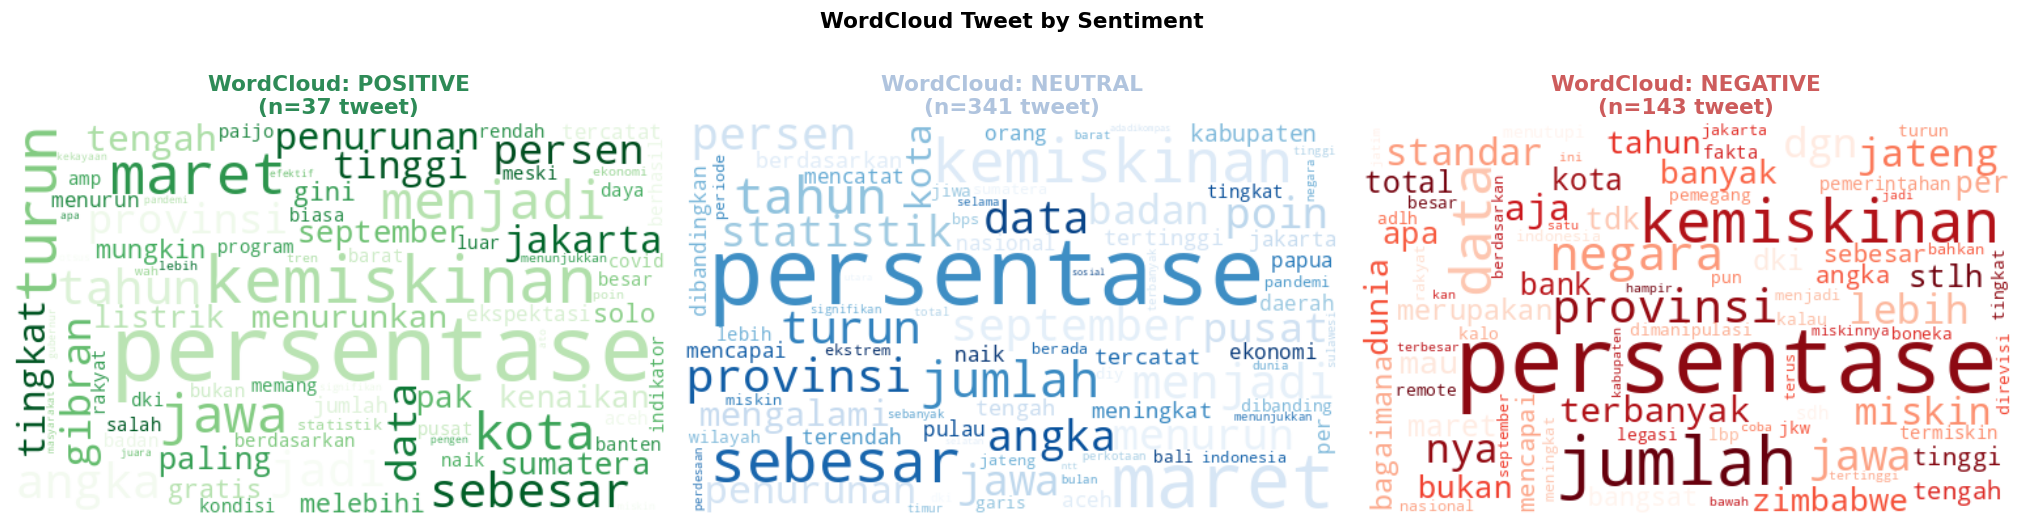

In [35]:
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for idx, sent in enumerate(sent_order):
        ax = axes[idx]
        texts_sent = df_result[df_result['sentiment'] == sent]['text_clean'].tolist()
        combined_text = ' '.join(texts_sent)

        words_filtered = [w for w in combined_text.split() if w not in stopwords_id and len(w) > 2]
        combined_filtered = ' '.join(words_filtered)

        if len(combined_filtered.strip()) > 10:
            wc = WordCloud(
                width=500, height=300,
                background_color='white',
                colormap={'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}[sent],
                max_words=80,
                collocations=False
            ).generate(combined_filtered)
            ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'WordCloud: {sent.upper()}\n(n={len(texts_sent)} tweet)',
                     color=SENT_COLORS[sent], fontweight='bold')

    plt.suptitle('WordCloud Tweet by Sentiment', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'plot_sentiment_wordcloud.png', bbox_inches='tight')
    plt.show()
except ImportError:
    print('WordCloud is not available. Skipping this step.')


In [36]:
fig_overall = make_subplots(rows=1, cols=3, specs=[[{"type": "pie"}, {"type": "bar"}, {"type": "histogram"}]])
wedge_colors = [SENT_COLORS.get(s, 'gray') for s in sent_order]
fig_overall.add_trace(go.Pie(labels=sent_counts.index, values=sent_counts.values, marker=dict(colors=wedge_colors), textinfo='percent+label'), row=1, col=1)
fig_overall.add_trace(go.Bar(x=sent_counts.index, y=sent_counts.values, marker_color=wedge_colors), row=1, col=2)
for sent in sent_order:
    sub = df_result[df_result['sentiment'] == sent]['confidence']
    if len(sub) > 0:
        fig_overall.add_trace(go.Histogram(x=sub, name=sent, marker_color=SENT_COLORS[sent], opacity=0.6), row=1, col=3)
fig_overall.update_layout(barmode='overlay', height=500, width=1400, showlegend=False)
fig_overall.write_json(OUTPUT_DIR / 'plot_sentiment_overall.json')
fig_overall.show()

## Save Output Files

In [37]:
cols_output = [
    'tweet_id', 'timestamp', 'year', 'month', 'date',
    'username', 'text', 'text_clean',
    'like', 'retweet', 'reply', 'quote',
    'sentiment', 'confidence',
    'score_positive', 'score_neutral', 'score_negative'
]
cols_output_valid = [c for c in cols_output if c in df_result.columns]

df_out1 = df_result[cols_output_valid].copy()
df_out1 = df_out1.sort_values(['year', 'month']).reset_index(drop=True)
df_out1.to_csv(OUTPUT_DIR / 'output_sentiment_per_tweet.csv', index=False)
print(f'Saved: output_sentiment_per_tweet.csv ({len(df_out1)} rows)')
print(df_out1.head(5).to_string(index=False))
print()

agg_yearmonth = df_result.groupby(['year', 'month', 'sentiment']).agg(
    tweet_count=('sentiment', 'count'),
    avg_confidence=('confidence', 'mean'),
    avg_like=('like', 'mean'),
    avg_retweet=('retweet', 'mean')
).reset_index()

agg_yearmonth.to_csv(OUTPUT_DIR / 'output_sentiment_monthly_aggregate.csv', index=False)
print(f'Saved: output_sentiment_monthly_aggregate.csv ({len(agg_yearmonth)} rows)')
print(agg_yearmonth.head(12).round(4).to_string(index=False))
print()

agg_year = df_result.groupby(['year', 'sentiment']).agg(
    tweet_count=('sentiment', 'count'),
    avg_confidence=('confidence', 'mean'),
    total_like=('like', 'sum'),
    total_retweet=('retweet', 'sum')
).reset_index()

total_per_year = df_result.groupby('year').size().rename('total_tweets')
agg_year = agg_year.merge(total_per_year, on='year')
agg_year['sentiment_percent'] = (agg_year['tweet_count'] / agg_year['total_tweets'] * 100).round(2)

agg_year.to_csv(OUTPUT_DIR / 'output_sentiment_yearly_aggregate.csv', index=False)
print(f'Saved: output_sentiment_yearly_aggregate.csv ({len(agg_year)} rows)')
print(agg_year.round(4).to_string(index=False))


Saved: output_sentiment_per_tweet.csv (521 rows)
           tweet_id                 timestamp  year  month       date       username                                                                                                                                                                                                                                                                                                       text                                                                                                                                                                                                                                             text_clean  like  retweet  reply  quote sentiment  confidence  score_positive  score_neutral  score_negative
1347846244408782848 2021-01-09 17:02:41+07:00  2021      1 2021-01-09 DidikMukrianto                                                                            3. Persentase penduduk miskin Jawa Timur th 2020 sebesar 11,09

In [38]:
print('ROBERTA SENTIMENT ANALYSIS SUMMARY')
print(f'Model            : {loaded_model_name}')
print(f'Device           : {"GPU" if device == 0 else "CPU"}')
print(f'Total tweets      : {len(df_result)}')
print(f'Time range    : {df_result["year"].min()} - {df_result["year"].max()}')
print()
print('Sentiment Distribution:')
for s in sent_order:
    n = len(df_result[df_result['sentiment'] == s])
    pct = n / len(df_result) * 100
    avg_conf = df_result[df_result['sentiment'] == s]['confidence'].mean()
    print(f'  {s:10s}: {n:4d} tweet ({pct:5.1f}%), avg confidence = {avg_conf:.4f}')
print()
print('CSV Outputs:')
print('  1. output_sentiment_per_tweet.csv         -> Sentiment by tweet')
print('  2. output_sentiment_monthly_aggregate.csv   -> Year-month aggregate')
print('  3. output_sentiment_yearly_aggregate.csv   -> Year aggregate')


ROBERTA SENTIMENT ANALYSIS SUMMARY
Model            : w11wo/indonesian-roberta-base-sentiment-classifier
Device           : GPU
Total tweets      : 521
Time range    : 2021 - 2026

Sentiment Distribution:
  positive  :   37 tweet (  7.1%), avg confidence = 0.6969
  neutral   :  341 tweet ( 65.5%), avg confidence = 0.8713
  negative  :  143 tweet ( 27.4%), avg confidence = 0.8597

CSV Outputs:
  1. output_sentiment_per_tweet.csv         -> Sentiment by tweet
  2. output_sentiment_monthly_aggregate.csv   -> Year-month aggregate
  3. output_sentiment_yearly_aggregate.csv   -> Year aggregate
